In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
end_date = datetime.strptime('2020-01-01', '%Y-%m-%d')
start_date = end_date - timedelta(days=365*5)

In [3]:
tickers = ['GOOGL', 'TSLA', 'AMZN', 'JPM', 'XOM', 'ASML', 'RACE', 'SIE.DE', 'GLD', 'BTC-USD']

returns_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna() 
print(returns_df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2015-11-01  0.034527  0.112743  0.062151  0.045310 -0.013053 -0.000755   
2015-12-01  0.019873  0.042343  0.016682 -0.009748 -0.037111 -0.042601   
2016-01-01 -0.021414 -0.203367 -0.131515 -0.098895 -0.001283  0.034584   
2016-02-01 -0.057963  0.003818 -0.058739 -0.047434  0.029544 -0.008928   
2016-03-01  0.063690  0.197155  0.074423  0.051865  0.052385  0.102944   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2015-11-01 -0.080904  0.072568 -0.067521  0.201024  
2015-12-01  0.035599 -0.084166 -0.004513  0.141116  
2016-01-01 -0.171459 -0.018914  0.054110 -0.143532  
2016-02-01 -0.045009  0.012546  0.109303  0.186920  
2016-03-01  0.097946  0.089983 -0.008429 -0.047905  


In [4]:
data_rf = yf.download('^TYX', start=start_date, end=end_date, interval='1mo')
rf_annual_pct = data_rf["Close"].mean()
rf = float(rf_annual_pct / 100) 
rf = (1 + rf)**(1/12) - 1  
print(rf)

[*********************100%***********************]  1 of 1 completed

0.0022959950457945855



C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\3818144123.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf = float(rf_annual_pct / 100)


In [5]:
spy_data = yf.download('SPY', start=start_date, end=end_date, interval='1mo')
spy_returns = spy_data["Close"].pct_change()
spy_returns = spy_returns.dropna()
spy_returns = spy_returns.loc[returns_df.index]
spy_mean = float(spy_returns.mean())
spy_var = float(spy_returns.var())

print(spy_returns.head())

[*********************100%***********************]  1 of 1 completed

Ticker           SPY
Date                
2015-11-01  0.003655
2015-12-01 -0.023096
2016-01-01 -0.044131
2016-02-01 -0.000826
2016-03-01  0.061790



C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\2182183759.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_mean = float(spy_returns.mean())
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\2182183759.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_var = float(spy_returns.var())


In [6]:
excess_returns = returns_df - rf
print(excess_returns.head())

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2015-11-01  0.032231  0.110448  0.059855  0.043014 -0.015349 -0.003051   
2015-12-01  0.017577  0.040047  0.014386 -0.012044 -0.039407 -0.044897   
2016-01-01 -0.023710 -0.205663 -0.133811 -0.101191 -0.003579  0.032288   
2016-02-01 -0.060259  0.001522 -0.061035 -0.049730  0.027248 -0.011224   
2016-03-01  0.061394  0.194859  0.072127  0.049569  0.050089  0.100648   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2015-11-01 -0.083200  0.070272 -0.069817  0.198728  
2015-12-01  0.033303 -0.086462 -0.006809  0.138820  
2016-01-01 -0.173755 -0.021210  0.051814 -0.145828  
2016-02-01 -0.047305  0.010250  0.107007  0.184624  
2016-03-01  0.095650  0.087687 -0.010725 -0.050201  


In [7]:
p_excess_returns = spy_returns - rf
print(p_excess_returns.head())

Ticker           SPY
Date                
2015-11-01  0.001359
2015-12-01 -0.025392
2016-01-01 -0.046427
2016-02-01 -0.003122
2016-03-01  0.059494


In [8]:
T = 0
for t in p_excess_returns.iloc:
    T += 1
print(T)

50


In [9]:
re_mean = excess_returns.mean()
f_mean = p_excess_returns.mean()
f_var = p_excess_returns.var()

In [10]:
betas = []
alfas = []

for col in excess_returns.columns:
    num = 0
    den = 0
    
    f_t_values = p_excess_returns['SPY'].astype(float)
    re_t_values = excess_returns[col].astype(float)
    
    f_mean = f_t_values.mean()
    re_mean = re_t_values.mean()
    
    for f_t, re_t in zip(f_t_values, re_t_values):
        num += (f_t - f_mean) * (re_t - re_mean)
        den += (f_t - f_mean) ** 2
    
    beta = num / den
    betas.append(beta)

    alfa = re_t - beta * f_mean
    alfas.append(alfa)

In [11]:
def get_stock_name(ticker_symbol: str):
    ticker = yf.Ticker(ticker_symbol)
    info = ticker.info
    return info.get("longName", "Nome non disponibile")

portfolio = []

for ticker in tickers:
    stock = get_stock_name(ticker)
    portfolio.append(stock)

print(portfolio)

['Alphabet Inc.', 'Tesla, Inc.', 'Amazon.com, Inc.', 'JPMorgan Chase & Co.', 'Exxon Mobil Corporation', 'ASML Holding N.V.', 'Ferrari N.V.', 'Siemens Aktiengesellschaft', 'SPDR Gold Shares', 'Bitcoin USD']


In [12]:
OLS_matrix = pd.DataFrame({
    'Titolo': portfolio,
    'Alpha': alfas,
    'Beta': betas
}, index=excess_returns.columns)
OLS_matrix.index.name = 'Ticker'

print(OLS_matrix)

                             Titolo     Alpha      Beta
Ticker                                                 
GOOGL                 Alphabet Inc.  0.016014  1.014979
TSLA                    Tesla, Inc.  0.258093  0.870044
AMZN               Amazon.com, Inc.  0.010272  1.570589
JPM            JPMorgan Chase & Co.  0.045338  1.199393
XOM         Exxon Mobil Corporation  0.026113  0.945744
ASML              ASML Holding N.V.  0.084866  1.292043
RACE                   Ferrari N.V. -0.029715  1.297274
SIE.DE   Siemens Aktiengesellschaft -0.014715  0.865220
GLD                SPDR Gold Shares  0.035442 -0.136601
BTC-USD                 Bitcoin USD -0.051979  0.000760


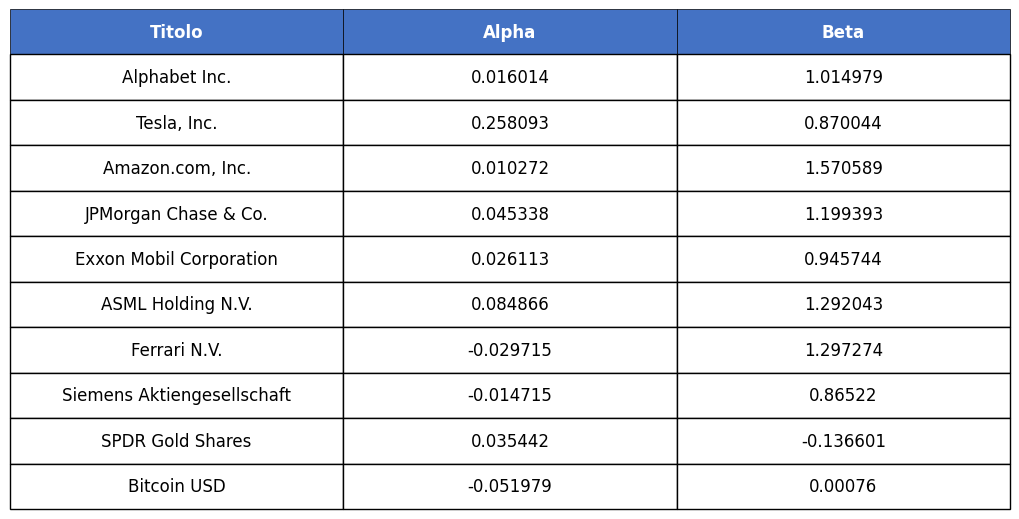

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

table = ax.table(cellText=OLS_matrix.round(6).values,
                colLabels=OLS_matrix.columns,
                cellLoc='center',
                bbox=[0, 0, 1, 1])  

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)  

for j in range(len(OLS_matrix.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_edgecolor('black')
    table[(0, j)].set_linewidth(0.5)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [14]:
errors_matrix = np.zeros((len(alfas), len(alfas)))  # inizializza matrice NxN

for re, f_t in zip(excess_returns.values, p_excess_returns['SPY'].values):
    eps_t = re - np.array(alfas) - np.array(betas) * f_t
    
    errors_matrix += np.outer(eps_t, eps_t)

errors_matrix = errors_matrix / T

errors_matrix_df = pd.DataFrame(errors_matrix, index=tickers, columns=tickers)

print(errors_matrix_df) 

            GOOGL      TSLA      AMZN       JPM       XOM      ASML      RACE  \
GOOGL    0.001857  0.003769  0.000581  0.000120 -0.000092  0.001645 -0.000486   
TSLA     0.003769  0.075340  0.000161  0.009503  0.008429  0.018081 -0.011087   
AMZN     0.000581  0.000161  0.003050 -0.000415 -0.000374 -0.000010  0.001189   
JPM      0.000120  0.009503 -0.000415  0.003296  0.001217  0.002528 -0.002450   
XOM     -0.000092  0.008429 -0.000374  0.001217  0.003016  0.002515 -0.001963   
ASML     0.001645  0.018081 -0.000010  0.002528  0.002515  0.007444 -0.002531   
RACE    -0.000486 -0.011087  0.001189 -0.002450 -0.001963 -0.002531  0.007106   
SIE.DE   0.000139 -0.003426 -0.000481  0.000004 -0.000095 -0.000473  0.000064   
GLD      0.000103  0.008023 -0.000083  0.000355  0.001032  0.002517 -0.000982   
BTC-USD -0.002730 -0.036035  0.000502 -0.005246 -0.006385 -0.012706  0.008410   

           SIE.DE       GLD   BTC-USD  
GOOGL    0.000139  0.000103 -0.002730  
TSLA    -0.003426  0.008023 

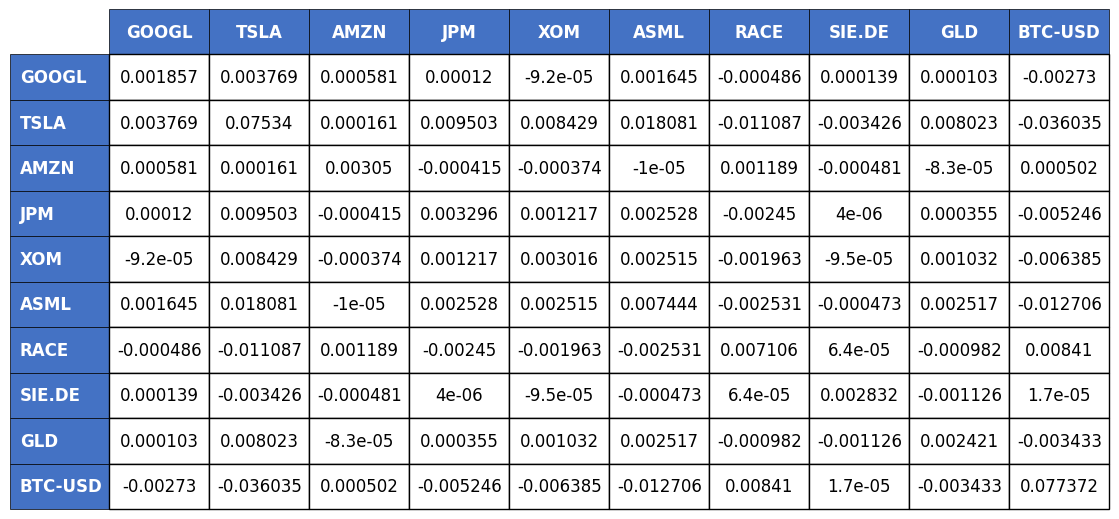

In [15]:
row_labels = errors_matrix_df.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Crea la tabella con colLabels e rowLabels uguali
table = ax.table(
    cellText=errors_matrix_df.round(6).values,
    colLabels=errors_matrix_df.columns,
    rowLabels=row_labels,
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)  

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)  

# Colora intestazioni delle colonne
for j in range(len(errors_matrix_df.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_edgecolor('black')
    table[(0, j)].set_linewidth(0.5)

# Colora intestazioni delle righe
for i in range(len(row_labels)):
    table[(i+1, -1)].set_facecolor('#4472C4')  # -1 corrisponde alla colonna delle rowLabels
    table[(i+1, -1)].set_text_props(weight='bold', color='white')
    table[(i+1, -1)].set_edgecolor('black')
    table[(i+1, -1)].set_linewidth(0.5)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [16]:
errors_matrix_inv = np.linalg.inv(errors_matrix)

errors_matrix_inv_df = pd.DataFrame(errors_matrix_inv, index=tickers, columns=tickers)
errors_matrix_inv_df = errors_matrix_inv_df.round(4)

print(errors_matrix_inv_df)

             GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
GOOGL    1151.3198  -74.1708 -164.5438  424.9835  351.8993 -468.8241   
TSLA      -74.1708   55.6504  -12.0726 -100.1994  -51.6797  -22.9661   
AMZN     -164.5438  -12.0726  405.8376    4.0843  -14.6939   37.9357   
JPM       424.9835 -100.1994    4.0843  813.6423  127.5198 -307.4491   
XOM       351.8993  -51.6797  -14.6939  127.5198  654.7279 -197.9730   
ASML     -468.8241  -22.9661   37.9357 -307.4491 -197.9730  634.4726   
RACE      142.4772    8.7866  -85.5866  162.7790   99.5049 -109.5757   
SIE.DE    -47.8674   22.3943   83.6527   11.7447  -58.4390  -84.5539   
GLD       494.0232 -102.8223   34.1988  515.5124   93.9064 -473.3471   
BTC-USD    -5.5367    3.0270    2.0338  -11.3156   11.9754   30.4470   

             RACE    SIE.DE        GLD  BTC-USD  
GOOGL    142.4772  -47.8674   494.0232  -5.5367  
TSLA       8.7866   22.3943  -102.8223   3.0270  
AMZN     -85.5866   83.6527    34.1988   2.0338  
JPM    

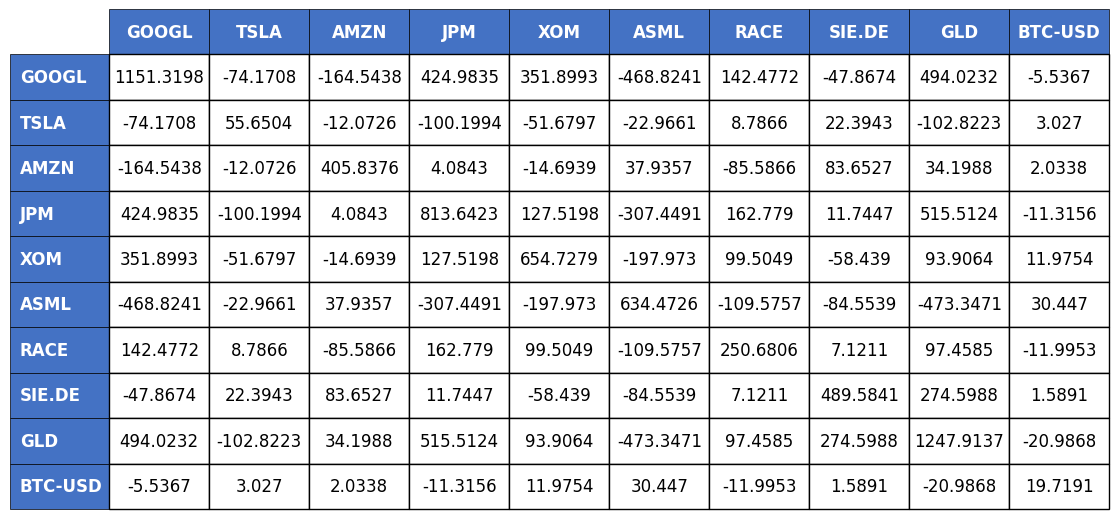

In [17]:
row_labels = errors_matrix_inv_df.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Crea la tabella con colLabels e rowLabels uguali
table = ax.table(
    cellText=errors_matrix_inv_df.round(6).values,
    colLabels=errors_matrix_inv_df.columns,
    rowLabels=row_labels,
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)  

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)  

# Colora intestazioni delle colonne
for j in range(len(errors_matrix_inv_df.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_edgecolor('black')
    table[(0, j)].set_linewidth(0.5)

# Colora intestazioni delle righe
for i in range(len(row_labels)):
    table[(i+1, -1)].set_facecolor('#4472C4')  # -1 corrisponde alla colonna delle rowLabels
    table[(i+1, -1)].set_text_props(weight='bold', color='white')
    table[(i+1, -1)].set_edgecolor('black')
    table[(i+1, -1)].set_linewidth(0.5)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [18]:
theta_sq = (f_mean**2)/f_var
N = len(tickers)

In [19]:
J_0 = T*((alfas@errors_matrix_inv@alfas)/(1+theta_sq))
print(float(J_0))

65.28193355342354


C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\534702862.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(J_0))


In [20]:
df = N # Gradi di libertà
chi2_observed = float(J_0)

p_value_chi = 1 - stats.chi2.cdf(chi2_observed, df)

print(f"p-value: {p_value_chi}")

p-value: 3.5798186637236995e-10


C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\4203645691.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  chi2_observed = float(J_0)


In [21]:
J_1 = ((T-N-1)/N)*((alfas@errors_matrix_inv_df@alfas)/(1+theta_sq))
print(float(J_1))

5.091980509795227


C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\4257121234.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(float(J_1))


In [22]:
df1 = N  
df2 = T-N-1  
f_observed = float(J_1)
p_value_f = 1 - stats.f.cdf(f_observed, df1, df2)
critical_value = stats.f.ppf(0.95,df1,df2)

print(f'p-value: {p_value_f}')
print(f'Valore critico: {critical_value}')

p-value: 9.813796142466025e-05
Valore critico: 2.0838689618562323


C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\3269702120.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f_observed = float(J_1)


C:\Users\Riccardo\AppData\Local\Temp\ipykernel_2260\202104779.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f_observed = float(J_1)


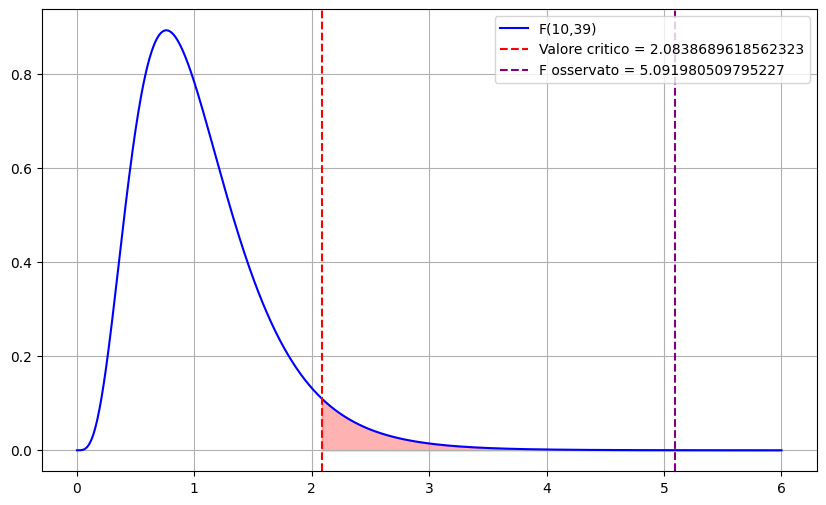

In [23]:
x = np.linspace(0, 6, 1000)

y = stats.f.pdf(x, df1, df2)

# Calcolo p-value e valore critico
f_observed = float(J_1)
p_value = 1 - stats.f.cdf(f_observed, df1, df2)
critical_value = stats.f.ppf(0.95,df1,df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', label=f'F({df1},{df2})')
plt.fill_between(x[x >= critical_value], y[x >= critical_value], color='red',alpha=0.3)
plt.axvline(critical_value, color='r', linestyle='--', label=f'Valore critico = {critical_value}')
plt.axvline(f_observed, color='purple', linestyle='--', label=f'F osservato = {f_observed}')

plt.legend()
plt.grid(True)
plt.show()

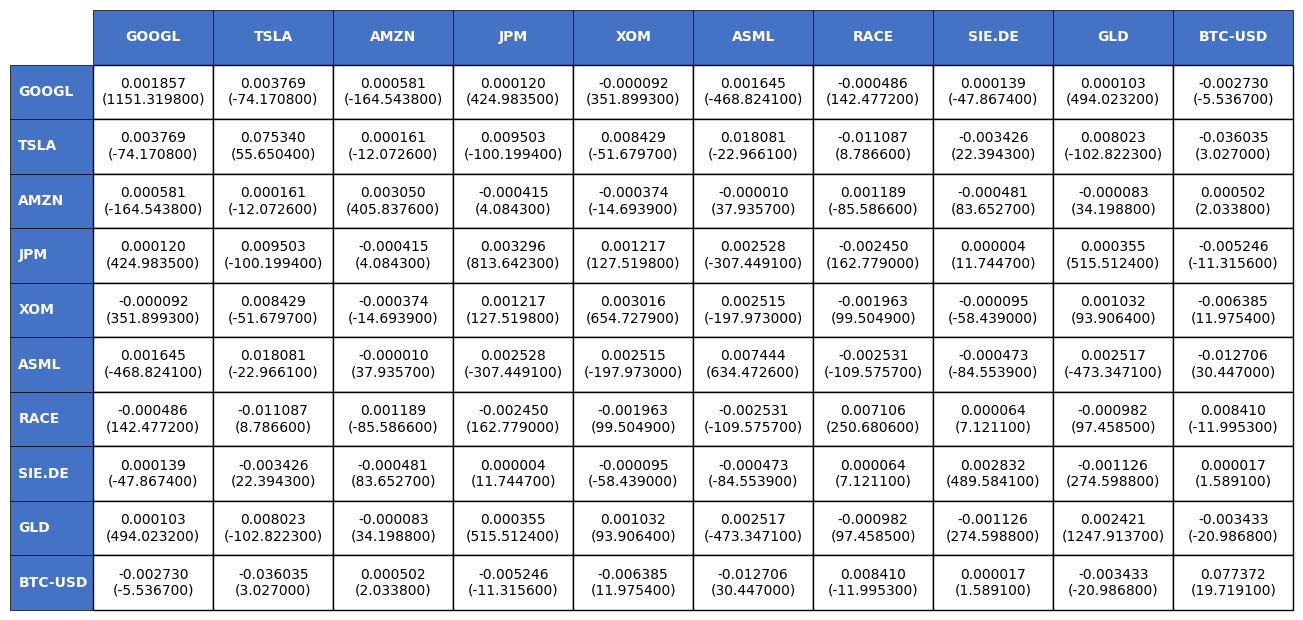

In [24]:
row_labels = errors_matrix_df.columns.tolist()

# Creare una matrice combinata dove ogni elemento è una stringa con due valori
combined_values = []
for i in range(len(errors_matrix_df)):
    row = []
    for j in range(len(errors_matrix_df)):
        val1 = f"{errors_matrix_df.iloc[i,j]:.6f}"
        val2 = f"({errors_matrix_inv_df.iloc[i,j]:.6f})"
        row.append(f"{val1}\n{val2}")
    combined_values.append(row)

fig, ax = plt.subplots(figsize=(12, 6))  # Aumentato leggermente la dimensione
ax.axis('off')

# Crea la tabella con i valori combinati
table = ax.table(
    cellText=combined_values,
    colLabels=errors_matrix_df.columns,
    rowLabels=row_labels,
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)  

table.auto_set_font_size(False)
table.set_fontsize(10)  # Ridotto leggermente il font size per accomodare più testo
table.scale(1, 2)  # Aumentato l'altezza delle celle per il testo su due righe

# Colora intestazioni delle colonne
for j in range(len(errors_matrix_df.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_edgecolor('black')
    table[(0, j)].set_linewidth(0.5)

# Colora intestazioni delle righe
for i in range(len(row_labels)):
    table[(i+1, -1)].set_facecolor('#4472C4')
    table[(i+1, -1)].set_text_props(weight='bold', color='white')
    table[(i+1, -1)].set_edgecolor('black')
    table[(i+1, -1)].set_linewidth(0.5)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()